# Fiap - Pós Tech IA para Devs

## Tech Challenger Fase 03 - OpenAI

### Sessão 1: Configuração do Ambiente Local (Ollama + LangGraph)

In [1]:
!uv add langchain-ollama

Resolved 114 packages in 1ms
Checked 109 packages in 12ms


In [2]:
from langchain_ollama import OllamaLLM

# Inicializa o modelo que você baixou
# modelo_local = OllamaLLM(model="llama3.2:3b")
modelo_local = OllamaLLM(model="llama3.2:1b")

# Teste simples
resposta = modelo_local.invoke("Olá! Você está rodando localmente?")
print(resposta)

ResponseError: model requires more system memory (1.3 GiB) than is available (1.1 GiB) (status code: 500)

### Sessão 2: Definição do Estado do Paciente (O State)

In [ ]:
from typing import Annotated, TypedDict, List
import operator

# Esta classe define o que o nosso sistema "lembra" sobre o atendimento
class PatientState(TypedDict):
    # O relato inicial da paciente
    relato: str 
    
    # A categoria decidida pelo roteador (Ex: 'clinico', 'urgencia', 'violencia')
    categoria: str 
    
    # Nível de risco (Verde, Amarelo, Vermelho)
    risco: str 
    
    # Lista de exames que o sistema identificar como necessários
    exames_sugeridos: Annotated[List[str], operator.add] 
    
    # Se o protocolo de segurança para violência deve ser ativado
    protocolo_seguranca: bool 
    
    # A resposta final que o modelo vai gerar
    resposta_final: str

### Sessão 3: Base de Dados e Conhecimento (RAG + Prontuário)

In [ ]:
# Sessão 3: Base de Dados e Conhecimento
import datetime

# Banco de dados fictício de pacientes
# Chave: Nome da paciente (em um sistema real seria um ID ou CPF)
PRONTUARIO_DB = {
    "Ana Silva": {
        "nascimento": "1985-05-20",
        "ultimo_papanicolau": "2020-10-15",
        "ultima_mamografia": "2023-01-10",
        "historico_violencia": False
    },
    "Maria Oliveira": {
        "nascimento": "1998-03-12",
        "ultimo_papanicolau": "2024-02-01",
        "ultima_mamografia": None,
        "historico_violencia": True
    },
    "Juliana Costa": {
        "nascimento": "1970-12-05",
        "ultimo_papanicolau": "2019-08-22",
        "ultima_mamografia": "2021-05-15",
        "historico_violencia": False
    }
}

def calcular_idade(data_nascimento: str) -> int:
    """Função utilitária para converter data em idade."""
    nascimento = datetime.datetime.strptime(data_nascimento, "%Y-%m-%d")
    hoje = datetime.datetime.now()
    return hoje.year - nascimento.year - ((hoje.month, hoje.day) < (nascimento.month, nascimento.day))

### Sessão 4: Construção dos Nós de Decisão (Nodes)

In [ ]:
# Sessão 4: Construção dos Nós de Decisão (Nodes)

def node_identificacao(state: PatientState):
    print("--- NÓ DE IDENTIFICAÇÃO ---")
    
    # Limpamos o nome (ex: "Juliana Costa: dor..." -> "Juliana Costa")
    nome_usuario = state['relato'].split(':')[0].strip()
    
    # Busca no banco de dados simulado (Sessão 3)
    dados_paciente = PRONTUARIO_DB.get(nome_usuario)

    exames_atrasados = []
    
    if dados_paciente:
            # Lógica simples para detectar exames antigos
            if "2019" in str(dados_paciente['ultimo_papanicolau']):
                exames_atrasados.append("Papanicolau")
            if "2021" in str(dados_paciente['ultima_mamografia']):
                exames_atrasados.append("Mamografia")
                
            return {
                "exames_sugeridos": exames_atrasados,
                "categoria": "identificada",
                "resposta_final": f"Prontuário de {nome_usuario} localizado."
            }
    
    return {"categoria": "nova_paciente"}

In [ ]:
def node_analise_clinica(state: PatientState):
    print("--- NÓ DE ANÁLISE CLÍNICA (DETETIVE) ---")
    relato = state['relato'].lower() # Convertemos para minúsculo para facilitar a busca
    exames_pendentes = state.get('exames_sugeridos', [])

    # --- TRAVA DE SEGURANÇA (Hardcoding) ---
    # Se detectarmos termos críticos, nem esperamos a IA decidir o risco
    termos_criticos = ["sangramento", "dor insuportável", "dor forte", "hemorragia", "aguda"]
    
    if any(termo in relato for termo in termos_criticos):
        cor_risco = "VERMELHO"
    else:
        # Se não for óbvio, pedimos a opinião da IA com um prompt bem curto
        prompt_curto = f"Classifique apenas com uma palavra (VERMELHO, AMARELO ou VERDE): {relato}"
        resposta = modelo_local.invoke(prompt_curto).strip().upper()
        
        if "VERMELHO" in resposta:
            cor_risco = "VERMELHO"
        elif "AMARELO" in resposta or len(exames_pendentes) > 0:
            cor_risco = "AMARELO"
        else:
            cor_risco = "VERDE"

    # Geramos a explicação final baseada no risco decidido
    if cor_risco == "VERMELHO":
        analise = "ESTADO DE EMERGÊNCIA DETECTADO. Procure um pronto-socorro imediatamente."
    else:
        analise = modelo_local.invoke(f"Explique brevemente este sintoma: {relato}")

    return {
        "risco": cor_risco,
        "resposta_final": analise
    }

In [ ]:
def node_prevencao_integracao(state: PatientState):
    print("--- NÓ DE PREVENÇÃO E INTEGRAÇÃO ---")
    
    # Buscamos os dados que já estão no 'State'
    exames = state.get('exames_sugeridos', [])
    relato = state['relato']
    
    prompt = f"""
    Relato da Paciente: {relato}
    Exames Pendentes no Prontuário: {', '.join(exames) if exames else 'Nenhum'}
    
    Responda ao relato dela. Se houver exames pendentes, explique de forma 
    gentil que seria ideal aproveitar a consulta para realizá-los, 
    conectando o motivo do contato com a importância da prevenção.
    """
    
    resposta = modelo_local.invoke(prompt)
    return {"resposta_final": resposta}

In [ ]:
def node_urgencia(state: PatientState):
    print("--- NÓ DE URGÊNCIA ---")
    relato = state['relato']
    
    prompt = f"""
    A paciente apresenta um quadro de urgência: {relato}.
    Responda de forma calma e profissional, orientando-a a procurar 
    o pronto-socorro ginecológico mais próximo imediatamente. 
    Não tente fazer diagnósticos, foque na segurança.
    """
    
    resposta = modelo_local.invoke(prompt)
    return {"resposta_final": resposta}

### Sessão 5: Montagem e Execução do Grafo

In [ ]:
def roteador_de_risco(state: PatientState):
    # O nó de análise clínica salvou o risco no estado
    risco = state.get("risco", "VERDE")
    
    if risco == "VERMELHO":
        return "urgencia"
    else:
        return "prevencao"

In [ ]:
from langgraph.graph import StateGraph, START, END

# 1. Criamos o esqueleto do grafo
workflow = StateGraph(PatientState)

# 2. Adicionamos os nós que já criamos nas sessões anteriores
workflow.add_node("identificacao", node_identificacao)
workflow.add_node("analise_clinica", node_analise_clinica)
workflow.add_node("urgencia", node_urgencia)
workflow.add_node("prevencao", node_prevencao_integracao)

# 3. Criamos as conexões (Edges)
workflow.add_edge(START, "identificacao")
workflow.add_edge("identificacao", "analise_clinica")

# 4. A parte "mágica": a conexão condicional
workflow.add_conditional_edges(
    "analise_clinica",
    roteador_de_risco,
    {
        "urgencia": "urgencia",
        "prevencao": "prevencao"
    }
)

# 5. Finalizamos o fluxo
workflow.add_edge("urgencia", END)
workflow.add_edge("prevencao", END)

# Compilamos o grafo para ele ficar pronto para uso
app = workflow.compile()

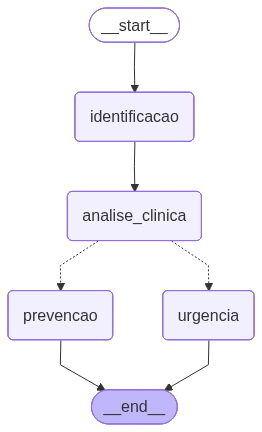

In [ ]:
from IPython.display import Image, display

try:
    # Gera o desenho do fluxo
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Caso não tenha as dependências de desenho instaladas
    print("Grafo compilado com sucesso! (Instale pygraphviz para visualizar o diagrama)")

In [ ]:
# Preparando a entrada com o caso da Juliana
inputs = {"relato": "Juliana Costa: sinto uma dor leve no fundo das costas ao acordar."}

# Executando o Grafo e guardando o resultado final
resultado_final = app.invoke(inputs)

# Agora sim podemos ver o que a IA decidiu!
print(f"Risco Definido: {resultado_final['risco']}")
print(f"Exames Identificados: {resultado_final['exames_sugeridos']}")
print("-" * 30)
print(f"Resposta Final do Sistema:\n{resultado_final['resposta_final']}")

--- NÓ DE IDENTIFICAÇÃO ---
--- NÓ DE ANÁLISE CLÍNICA (DETETIVE) ---
--- NÓ DE PREVENÇÃO E INTEGRAÇÃO ---
Risco Definido: AMARELO
Exames Identificados: ['Papanicolau', 'Mamografia']
------------------------------
Resposta Final do Sistema:
**Atenção aos Pacientes**

Sinto com peita a relato da senhora Juliana Costa sobre sentir dor leve no fundo das costas ao acordar. É importante lembrar que, além de uma consulta médica, é fundamental realizar exames pendentes para garantir a saúde e o bem-estar do paciente.

**Exames Pendentes no Prontuário**

A senhora Juliana Costa mencionou que há exames pendentes no prontuário. É essencial aproveitar essa oportunidade para realizar aqueles exames para garantir a saúde de sua saúde e prevenir possíveis problemas nos próximos meses.

**Importância da Prevenção**

A prevenção é uma das melhores estratégias para evitar complicações médicas futuras. Os exames pendentes são fundamentais para identificar condições temidas, como:

*   Papanicolau: uma ve

In [ ]:
# --- DESAFIO DE TESTE: CASO DE EMERGÊNCIA ---

# 1. Simulamos um relato de alto risco
inputs_urgente = {
    "relato": "Mariana Silva: Estou com uma dor abdominal insuportável e sangramento vivo intenso há duas horas.",
    "exames_sugeridos": [] # Mesmo sem exames pendentes, o sintoma deve mandar para o Vermelho
}

print(f"Testando relato: {inputs_urgente['relato']}")

# 2. Executando o Grafo
resultado_urgencia = app.invoke(inputs_urgente)

# 3. Verificação de Resultados
print("\n=== RESULTADO DO TESTE DE SEGURANÇA ===")
print(f"Risco Classificado: {resultado_urgencia['risco']}")
print("-" * 30)
print(f"Resposta Gerada para a Paciente:\n{resultado_urgencia['resposta_final']}")

Testando relato: Mariana Silva: Estou com uma dor abdominal insuportável e sangramento vivo intenso há duas horas.
--- NÓ DE IDENTIFICAÇÃO ---
--- NÓ DE ANÁLISE CLÍNICA (DETETIVE) ---
--- NÓ DE URGÊNCIA ---

=== RESULTADO DO TESTE DE SEGURANÇA ===
Risco Classificado: VERMELHO
------------------------------
Resposta Gerada para a Paciente:
Lamento ouvir sobre a situação da Mariana Silva. É importante agir com urgência e cuidados profissionais para garantir sua saúde.

Aqui está uma resposta calma e profissional:

"Mariana, é crucial que você procure o pronto-socorro ginecológico mais próximo imediatamente. A dor abdominal insuportável com sangramento vivo intenso pode ser sinal de várias condições graves, incluindo hemorragia intestinal, sangramento gastrointestinal ou até mesmo uma lesão no útero. É fundamental que você não tente diagnósticos ou tratamentos em casa."

"Por favor, entre em contato imediatamente com o telefone de emergência do hospital mais próximo e peça aconselhamento 

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

# 1. Criar a memória
memory = MemorySaver()

# 2. Compilar o grafo COM o checkpointer
app = workflow.compile(checkpointer=memory)

# 3. Para testar com memória, precisamos de um ID de conversa
config = {"configurable": {"thread_id": "paciente_mariana_01"}}

# Exemplo de execução
# Primeira interação:
# app.invoke({"relato": "Mariana: Estou com dor forte"}, config=config)

# Segunda interação (ele vai lembrar da Mariana):
# app.invoke({"relato": "Estou com muito medo"}, config=config)